## <span style='text-decoration: double underline;color:rgb(10,110,217)'>**Results Model 010**</span>

**Loss function configuration:**

$\lambda_{init} = 0$  
$\lambda_{phys} = 1$  
$\lambda_{bin} = 0$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../')

In [3]:
import utils.evaluation_tools as eval_tools

delta = 1 
shape = (20,20)
model_name = 'DiffGoLFin'
parent_folder = '../Data'
seed2plot = 221
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  

threshold = 0.5
figsize = (12,9)
subplots_grid = (3,3)
suptitle = 'DiffGoLFin Model'
th_ranges = [(0.45, 0.55), (0.40, 0.60), (0.35, 0.65)]

train_history_paths = eval_tools.get_paths_results('train_history.csv', parent_folder, seeds, shape, delta, model_name)
predictions_paths = eval_tools.get_paths_results('predictions.csv', parent_folder, seeds, shape, delta, model_name)
test_results_paths = eval_tools.get_paths_results('test_results.csv', parent_folder, seeds, shape, delta, model_name)
test_data = eval_tools.get_paths_results('test.npz', parent_folder, seeds, shape, delta, model_name)

### <span style='color:rgb(10,110,217)'><u>**Train Results**</u></span>

--- Metrics computed during execution ---
loss: 0.2443 ± 0.7769
val_loss: 0.2446 ± 0.7758


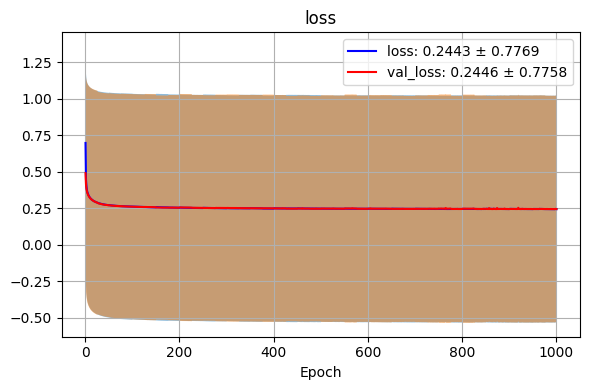

In [4]:
cols2omit = 1
num_rows = 1
eval_tools.display_results(train_history_paths, 'val_', cols2omit, num_rows, True, True)

### <span style='color:rgb(10,110,217)'><u>**Test Results**</u></span>

In [5]:
# Test:
eval_tools.display_results(test_results_paths, '_fin', display_plot=False)

--- Metrics computed during execution ---
Accuracy_init: 0.3201 ± 0.0256
Accuracy_fin: 0.9719 ± 0.0480
Recall_init: 0.2786 ± 0.1780
Recall_fin: 0.8718 ± 0.2330
Specificity_init: 0.3313 ± 0.0676
Specificity_fin: 0.9981 ± 0.0005
Precision_init: 0.0971 ± 0.0340
Precision_fin: 0.9257 ± 0.2474
F1Score_init: 0.1431 ± 0.0585
F1Score_fin: 0.8979 ± 0.2400


--- Results Initial States (15 seeds) ---
Density (true): 21.40% ± 8.99%
Density (pred): 57.45% ± 13.09%
Error/seed:     36.06% ± 2.50%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 9.81% ± 3.90%
HUC% (0.4, 0.6): 19.19% ± 7.31%
HUC% (0.35, 0.65): 27.70% ± 10.59%
Fuzziness Index: 0.4430 ± 0.1672
MSE (prob):0.5522 ± 0.1446
MSE (bin):0.6799 ± 0.1075
MSE (all-zero): 0.2140 ± 0.0899
Wasserstein (EMD): 3.4836 ± 0.2073


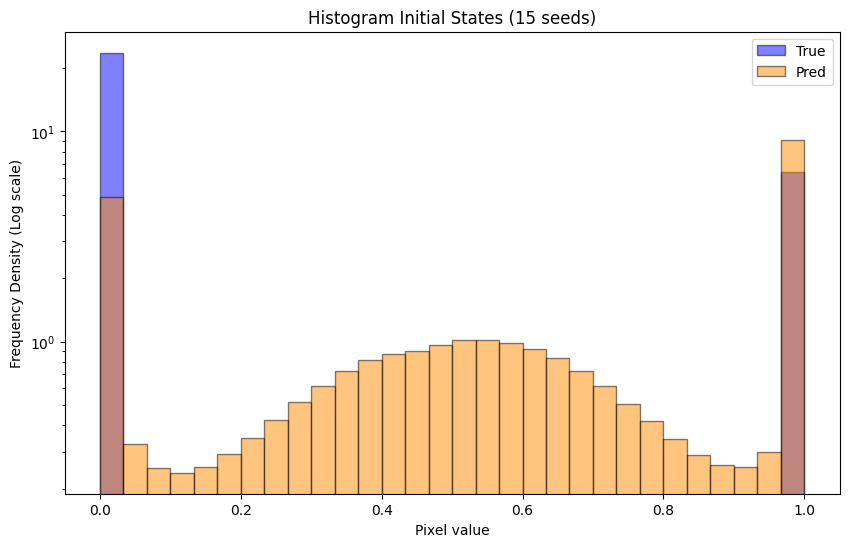

In [6]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'init', th_ranges, threshold, colors=['blue', 'darkorange'])

--- Results Final States (15 seeds) ---
Density (true): 20.74% ± 9.05%
Density (pred): 17.89% ± 7.18%
Error/seed:     2.84% ± 4.96%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 0.58% ± 0.16%
HUC% (0.4, 0.6): 1.17% ± 0.33%
HUC% (0.35, 0.65): 1.81% ± 0.50%
Fuzziness Index: 0.0748 ± 0.0662
MSE (prob):0.0251 ± 0.0556
MSE (bin):0.0281 ± 0.0563
MSE (all-zero): 0.2074 ± 0.0905
Wasserstein (EMD): 1.6920 ± 3.0431


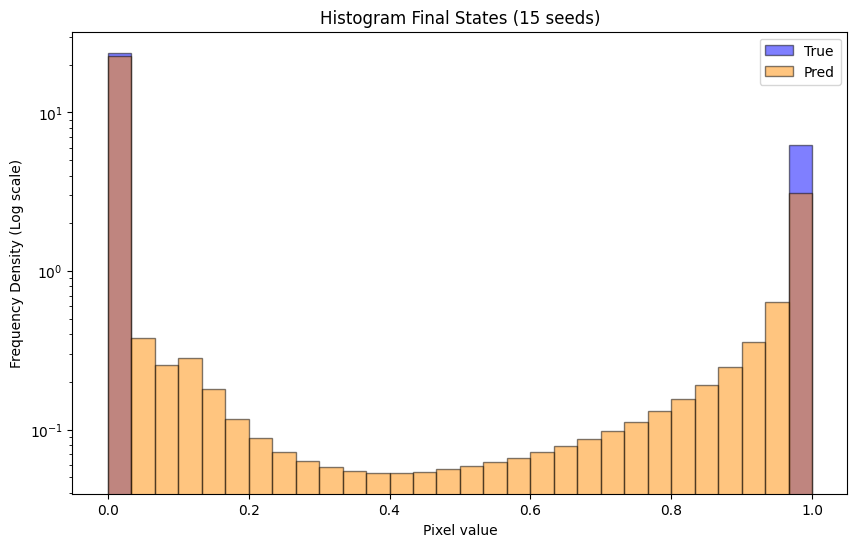

In [7]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'fin', th_ranges, threshold, colors=['blue', 'darkorange'])

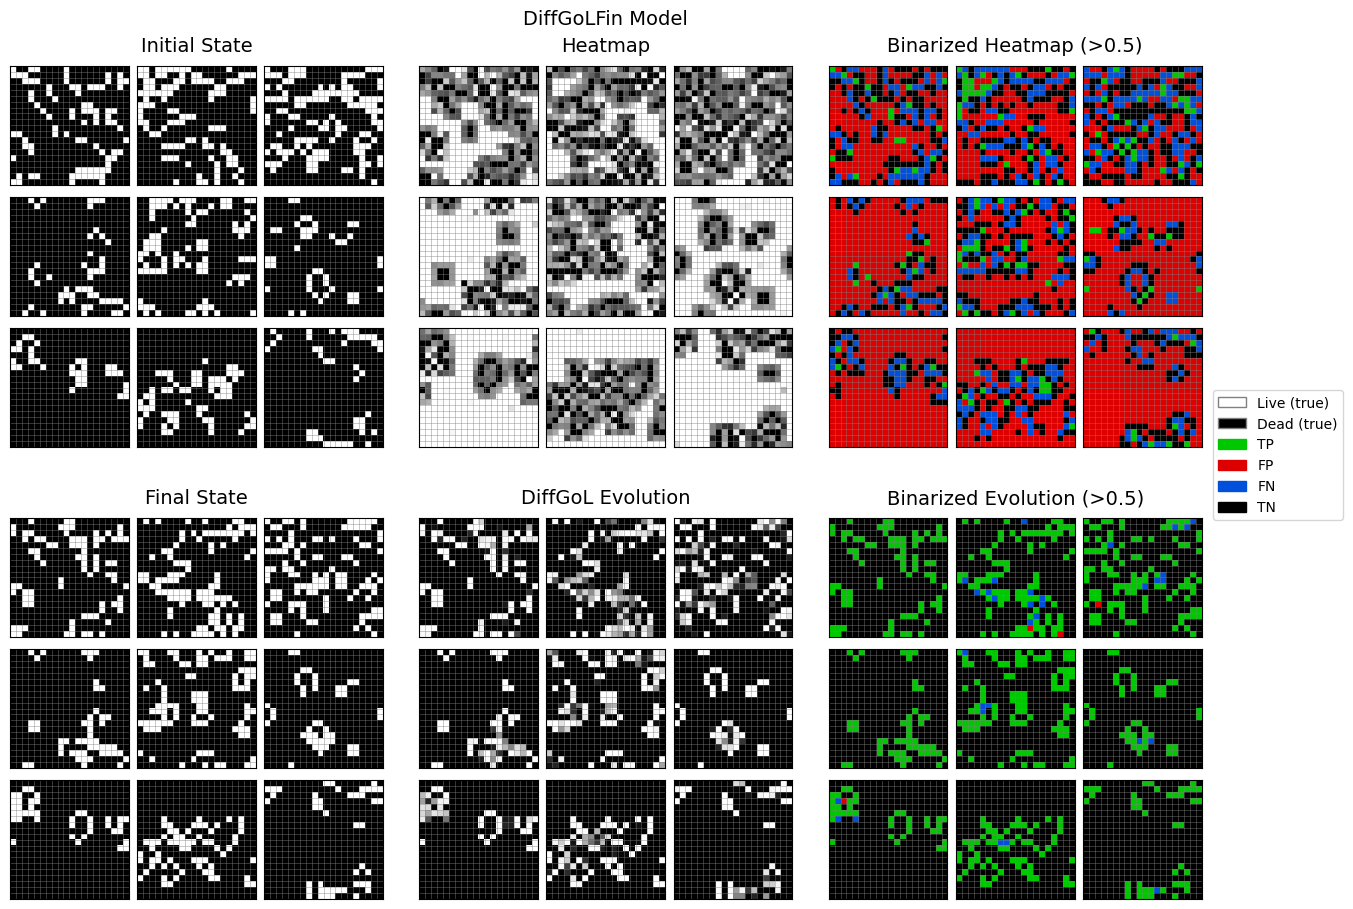

In [8]:
file_test = test_data[seed2plot]
file_pred = predictions_paths[seed2plot]
titles = ['Initial State', 'Heatmap', f'Binarized Heatmap (>{threshold})', 
          'Final State', 'DiffGoL Evolution', f'Binarized Evolution (>{threshold})']
eval_tools.display_states(file_pred, file_test, shape, threshold, titles, subplots_grid, suptitle, figsize, random=False)